# An analysis of the Glamsterdam 200M gas limit simulation

#### Maria Silva, September 2026

A full-range sweep of the Fusaka -> Glamsterdam gas-limit simulator, run
`20260907T122124Z`, over mainnet blocks 25,168,786-25,319,985 (~21 days,
151,200 source blocks). Each grid cell runs 50 resampled paths of 7,200 simulated
blocks - one day of chain time - while the gas limit ramps from 60M to 200M at
1/1024 per block.

The grid is elasticity {0.1, 0.2, 0.3} x demand level {1, 1.5, 2, 2.5}, 12 cells
in all. No cell hit the `MAX_BASE_FEE` or demand-multiplier guards, so every cell
here is interpretable.

The time-series sections focus on the **first 3,000 blocks**, which covers the
whole gas-limit ramp (it ends at block 1,234) and the settling after it. The
remaining 4,200 blocks are in the appendix.

**Mind the horizon.** At 7,200 blocks the ramp is 17% of the run, so "steady
state" here means the ~6,000 blocks after the ramp rather than a long-run
equilibrium. There is a convergence check below.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 15}
)

In [3]:
# Main directories
current_path = os.getcwd()
repo_dir = os.path.abspath(current_path)
output_dir = os.path.join(repo_dir, "output")
analysis_dir = os.path.join(output_dir, "analysis")
figs_dir = os.path.join(analysis_dir, "figs")
os.makedirs(figs_dir, exist_ok=True)

# The run this notebook analyses
run_dirs = [os.path.join(output_dir, "20260907T122124Z")]

zoom_blocks = 3000   # the transient window every time series shows
excluded_levels = []  # nothing hit a guard in this run
gas_limit = 200_000_000

# Run constants, taken from the manifest rather than hardcoded
with open(os.path.join(run_dirs[0], "manifest.json"), "r") as file:
    resolved = json.load(file)["resolved"]

start_fee_gwei = resolved["starting_base_fee_wei"] / 1e9  # base fee at block 0
anchor_fee_gwei = resolved["demand_anchor_price_wei"] / 1e9  # price the curve is anchored at
reference_gas = resolved["demand_reference_gas"]  # mean cohort gas, the demand unit
print(f"starting base fee   {start_fee_gwei:.4f} gwei")
print(f"demand anchor price {anchor_fee_gwei:.4f} gwei")
print(f"reference gas       {reference_gas:,.0f}")
print(f"horizon             {resolved['simulation_horizon_blocks']:,} blocks")

starting base fee   0.0847 gwei
demand anchor price 1.0130 gwei
reference gas       61,334,918
horizon             7,200 blocks


## Load and process data

In [4]:
steps_file = os.path.join(analysis_dir, "steps.parquet")
window_file = os.path.join(analysis_dir, "window.parquet")
steady_file = os.path.join(analysis_dir, "steady.parquet")

metrics = [
    "utilization", "execution_utilization", "state_utilization",
    "base_fee_gwei", "demand_multiplier", "tip_gwei",
    "backlog_txs", "eligible_backlog_txs",
    "base_fee_clamped", "demand_multiplier_clamped", "ramp_end_block",
]
keys = ["elasticity", "demand_level", "demand", "run_index"]

if os.path.exists(steps_file):
    steps_df = pd.read_parquet(steps_file)
    window_df = pd.read_parquet(window_file)
    steady_df = pd.read_parquet(steady_file)
else:
    steps_list, window_list, steady_list = [], [], []
    for run_dir in run_dirs:
        for file_path in sorted(glob.glob(os.path.join(run_dir, "per_step", "*.parquet"))):
            # File stems look like e0.1_d1.5_p16
            stem = os.path.basename(file_path).replace(".parquet", "")
            elasticity, demand_level, pool_blocks = [float(p[1:]) for p in stem.split("_")]
            if demand_level in excluded_levels:
                continue
            print(f"reading {stem}", flush=True)

            df = pd.read_parquet(file_path)
            # A block's gas used is max(execution, state): they share one limit
            df["gas_used"] = np.maximum(df["block_execution_gas_used"], df["block_state_gas_used"])
            df["utilization"] = df["gas_used"] / df["gas_limit"]
            df["execution_utilization"] = df["block_execution_gas_used"] / df["gas_limit"]
            df["state_utilization"] = df["block_state_gas_used"] / df["gas_limit"]
            df["base_fee_gwei"] = df["base_fee_per_gas"] / 1e9
            df["demand_multiplier"] = df["realized_demand_multiplier"]
            df["tip_gwei"] = df["priority_fees_wei"] / df["sender_gas_used"].clip(lower=1) / 1e9
            df["backlog_txs"] = df["backlog_tx_count"]
            df["eligible_backlog_txs"] = df["backlog_eligible_tx_count"]
            df["elasticity"] = elasticity
            df["demand_level"] = demand_level
            df["demand"] = f"{demand_level:g}x"
            # The ramp is over once the limit first reaches its ceiling
            df["ramp_end_block"] = df.loc[
                df["gas_limit"] == df["gas_limit"].max(), "simulation_position"
            ].min()

            # The transient, block by block. No binning, so the band seaborn draws
            # is the real spread across the 20 paths at each individual block
            zoom = df[df["simulation_position"] < zoom_blocks].copy()
            zoom["block"] = zoom["simulation_position"]
            steps_list.append(zoom[keys + ["block"] + metrics])

            # The full horizon, binned to ~300 points, for the appendix
            bin_width = max(1, (df["simulation_position"].max() + 1) // 300)
            df["block"] = df["simulation_position"] // bin_width * bin_width
            window_list.append(df.groupby(keys + ["block"], as_index=False)[metrics].mean())

            # Post-ramp sample, for the distributions and the per-cell table
            post_ramp = df[df["simulation_position"] >= df["ramp_end_block"].iloc[0]]
            steady_list.append(post_ramp.sample(20_000, random_state=0)[keys + metrics])

    steps_df = pd.concat(steps_list, ignore_index=True)
    window_df = pd.concat(window_list, ignore_index=True)
    steady_df = pd.concat(steady_list, ignore_index=True)
    steps_df.to_parquet(steps_file, index=False)
    window_df.to_parquet(window_file, index=False)
    steady_df.to_parquet(steady_file, index=False)

demand_order = sorted(steps_df["demand"].unique(), key=lambda s: float(s[:-1]))
ramp_end = int(steps_df["ramp_end_block"].max())
steps_df.info()

reading e0.1_d1.0_p16


reading e0.1_d1.5_p16


reading e0.1_d2.0_p16


reading e0.1_d2.5_p16


reading e0.2_d1.0_p16


...

reading e0.3_d1.0_p16


reading e0.3_d1.5_p16


reading e0.3_d2.0_p16


reading e0.3_d2.5_p16


<class 'pandas.DataFrame'>
RangeIndex: 1800000 entries, 0 to 1799999
Data columns (total 16 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   elasticity                 float64
 1   demand_level               float64
 2   demand                     str    
 3   run_index                  int64  
 4   block                      int64  
 5   utilization                float64
 6   execution_utilization      float64
 7   state_utilization          float64
 8   base_fee_gwei              float64
 9   demand_multiplier          float64
 10  tip_gwei                   float64
 11  backlog_txs                int64  
 12  eligible_backlog_txs       int64  
 13  base_fee_clamped           bool   
 14  demand_multiplier_clamped  bool   
 15  ramp_end_block             int64  
dtypes: bool(2), float64(8), int64(5), str(1)
memory usage: 201.1 MB


### One row per grid cell

In [5]:
cells_df = (
    steady_df.groupby(["elasticity", "demand_level", "demand"])
    .agg(
        utilization=("utilization", "median"),
        execution_utilization=("execution_utilization", "median"),
        state_utilization=("state_utilization", "median"),
        base_fee_gwei=("base_fee_gwei", "median"),
        tip_gwei=("tip_gwei", "median"),
        demand_multiplier=("demand_multiplier", "median"),
        backlog_txs=("backlog_txs", "median"),
        eligible_backlog_txs=("eligible_backlog_txs", "median"),
        saturated_share=("utilization", lambda s: (s >= 0.99).mean()),
    )
    .reset_index()
)
# A cell is "at target" once its equilibrium quantity reaches the ceiling
ceiling = cells_df["demand_multiplier"].max()
cells_df["regime"] = np.where(
    cells_df["demand_multiplier"] >= 0.99 * ceiling, "at target", "demand-limited"
)
cells_df.round(4)

,elasticity,demand_level,demand,utilization,execution_utilization,state_utilization,base_fee_gwei,tip_gwei,demand_multiplier,backlog_txs,eligible_backlog_txs,saturated_share,regime
0,0.1,1.0,1x,0.2824,0.2729,0.1611,0.0000,0.0243,1.3969,0.0,0.0,0.0,demand-limited
1,0.1,1.5,1.5x,0.4126,0.4015,0.2462,0.0000,0.0253,2.0940,0.0,0.0,0.0,demand-limited
2,0.1,2.0,2x,0.5015,0.4892,0.3039,0.0052,0.0662,2.5435,0.0,0.0,0.0,at target
3,0.1,2.5,2.5x,0.5008,0.4876,0.3042,0.3127,0.3471,2.5381,0.0,0.0,0.0,at target
4,0.2,1.0,1x,0.3859,0.3751,0.2297,0.0000,0.0248,1.9540,0.0,0.0,0.0,demand-limited
5,0.2,1.5,1.5x,0.4963,0.4840,0.3021,0.0021,0.0601,2.5376,0.0,0.0,0.0,at target
6,0.2,2.0,2x,0.4983,0.4856,0.3009,0.0602,0.1907,2.5369,0.0,0.0,0.0,at target
7,0.2,2.5,2.5x,0.4968,0.4840,0.3023,0.3700,0.3793,2.5366,199.0,0.0,0.0,at target
8,0.3,1.0,1x,0.4963,0.4835,0.3010,0.0002,0.0349,2.5421,0.0,0.0,0.0,at target
9,0.3,1.5,1.5x,0.4965,0.4839,0.3019,0.0257,0.1238,2.5367,0.0,0.0,0.0,at target


### Any clamping?

A cell whose base fee or demand multiplier hit its guard is not interpretable, so
both shares must be zero.

In [6]:
clamp_df = (
    steps_df.groupby(["elasticity", "demand"])[
        ["base_fee_clamped", "demand_multiplier_clamped"]
    ]
    .mean()
    .reset_index()
)
print("cells with any clamping:", (clamp_df.iloc[:, 2:] > 0).any(axis=1).sum())
print(f"the 1/1024 ramp reaches 200M at block {ramp_end:,}")
clamp_df

cells with any clamping: 0
the 1/1024 ramp reaches 200M at block 1,234


,elasticity,demand,base_fee_clamped,demand_multiplier_clamped
0,0.1,1.5x,0.0,0.0
1,0.1,1x,0.0,0.0
2,0.1,2.5x,0.0,0.0
3,0.1,2x,0.0,0.0
4,0.2,1.5x,0.0,0.0
5,0.2,1x,0.0,0.0
6,0.2,2.5x,0.0,0.0
7,0.2,2x,0.0,0.0
8,0.3,1.5x,0.0,0.0
9,0.3,1x,0.0,0.0


## Block utilization

`utilization = max(execution_gas, state_gas) / gas_limit`, since the two gas
dimensions share one limit. The line is the mean across the 20 paths and the band
their 10th-90th percentile at each block. The dashed rules are the EIP-1559 target
(50% of the limit) and the block where the ramp ends.

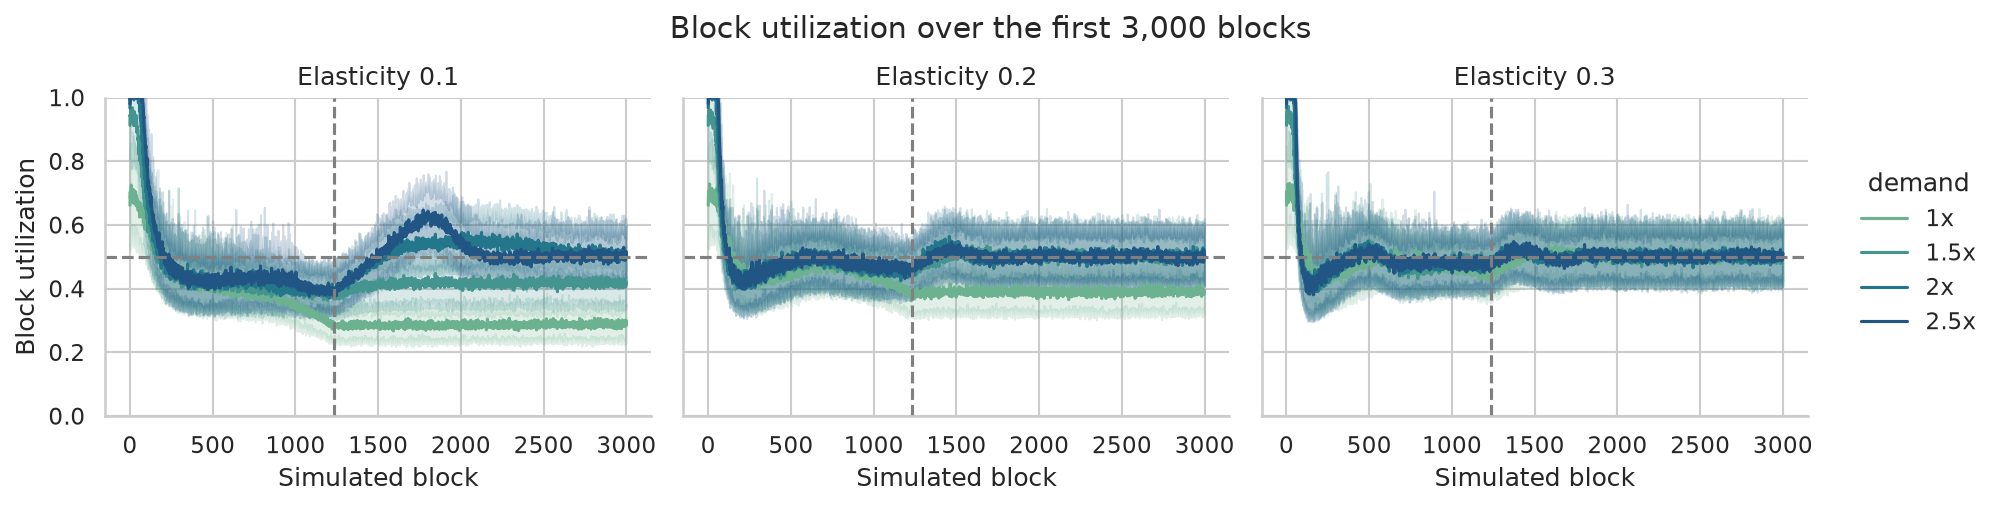

In [7]:
g = sns.relplot(
    data=steps_df,
    kind="line",
    x="block",
    y="utilization",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=0.5, color="grey")
g.refline(x=ramp_end, color="grey")
g.set(ylim=(0, 1), xlabel="Simulated block", ylabel="Block utilization")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Block utilization over the first {zoom_blocks:,} blocks", y=1.05)
plt.savefig(os.path.join(figs_dir, "utilization_transient.png"), bbox_inches="tight")
plt.show()

In [8]:
cells_df.pivot(index="demand", columns="elasticity", values="utilization").reindex(demand_order).round(3)

elasticity,0.1,0.2,0.3
demand,,,
1x,0.282,0.386,0.496
1.5x,0.413,0.496,0.497
2x,0.502,0.498,0.496
2.5x,0.501,0.497,0.496


### Takeaways

- **Utilization climbs to the 1559 target and stops there.** It never exceeds it,
  because the protocol targets half the limit and the demand model raises the base
  fee until arrivals fall back to that target.
- **Blocks run full early on** in the high-demand cells. 2.5x latent demand is
  ~153M gas of arrivals against a 60M starting limit, so the block cannot hold a
  step's worth of demand until the ramp has added most of its capacity.
- **At `e = 0.1` there is a post-ramp overshoot** around blocks 1,500-1,800. While
  the limit grows at 1/1024 per block the added capacity keeps demand chasing it;
  the moment growth stops, demand catches up and utilization runs above target
  until the fee corrects. The weaker the price response, the longer that takes.
- Steady-state medians run 28.2% to 50.2%. The three cells below target -
  `(0.1, 1x)`, `(0.1, 1.5x)` and `(0.2, 1x)` - are demand-limited: even a
  collapsed fee cannot lift their demand as far as the target. The other nine sit
  on it, at 49.6-50.2%.

## Base fee

Same facets, log scale. Identical utilization above, four orders of magnitude of
price here. This is where the settings actually separate.

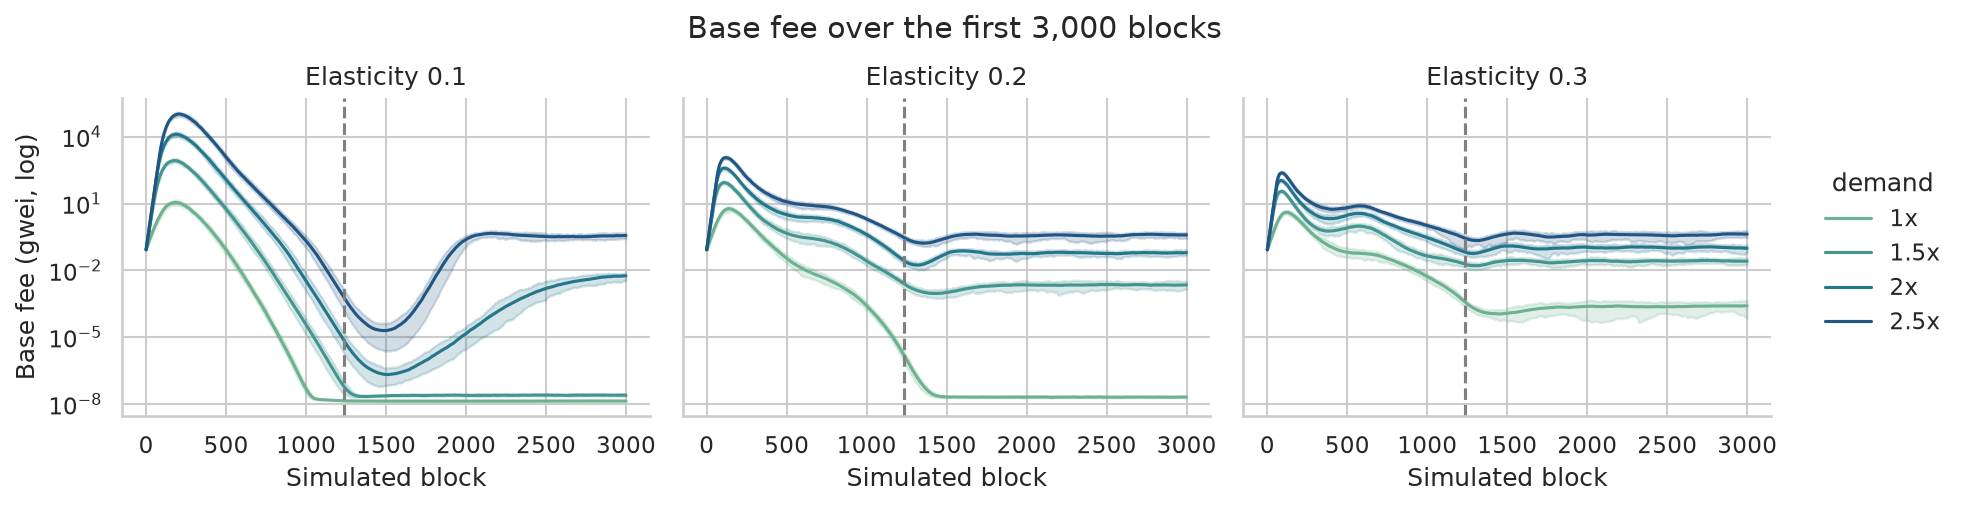

In [9]:
g = sns.relplot(
    data=steps_df,
    kind="line",
    x="block",
    y="base_fee_gwei",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(x=ramp_end, color="grey")
g.set(yscale="log", xlabel="Simulated block", ylabel="Base fee (gwei, log)")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Base fee over the first {zoom_blocks:,} blocks", y=1.05)
plt.savefig(os.path.join(figs_dir, "base_fee_transient.png"), bbox_inches="tight")
plt.show()

In [10]:
cells_df.pivot(index="demand", columns="elasticity", values="base_fee_gwei").reindex(demand_order).round(4)

elasticity,0.1,0.2,0.3
demand,,,
1x,0.0000,0.0000,0.0002
1.5x,0.0000,0.0021,0.0257
2x,0.0052,0.0602,0.1052
2.5x,0.3127,0.3700,0.3911


### Takeaways

- **The base fee, not the gas limit, is what absorbs higher demand.** The nine
  at-target cells all sit within 0.6pp of each other on utilization while their
  clearing fees span 0.0002 to 0.39 gwei - more than three orders of magnitude.
- **The transient dwarfs the steady state.** Every cell spikes over the first ~200
  blocks, decays as the ramp adds capacity, bottoms out around the end of the
  ramp, then settles up to its clearing level. The peak is orders of magnitude
  above the level the cell settles at.
- That spike is the model correctly pricing the scenario it was given, but the
  **scenario is artificial**: latent demand calibrated to a 200M world is applied
  in full from block 0 while the limit still starts at 60M. Real demand growth
  would arrive gradually and the spike would be far smaller.
- **Do not quote the peak as a forecast.** It supports "the transition is
  fee-violent if demand arrives faster than capacity", and it deserves its own
  experiment - ramping the demand level in step with the gas limit - which this
  grid does not do.

## Demand response

`demand_multiplier` is how much latent demand the model puts on the wire per
block: `demand_level * (price_signal / reference_price) ** -elasticity`. It starts
at exactly `demand_level`, because the price signal is seeded at the reference
price, and is thereafter driven only by the simulated price.

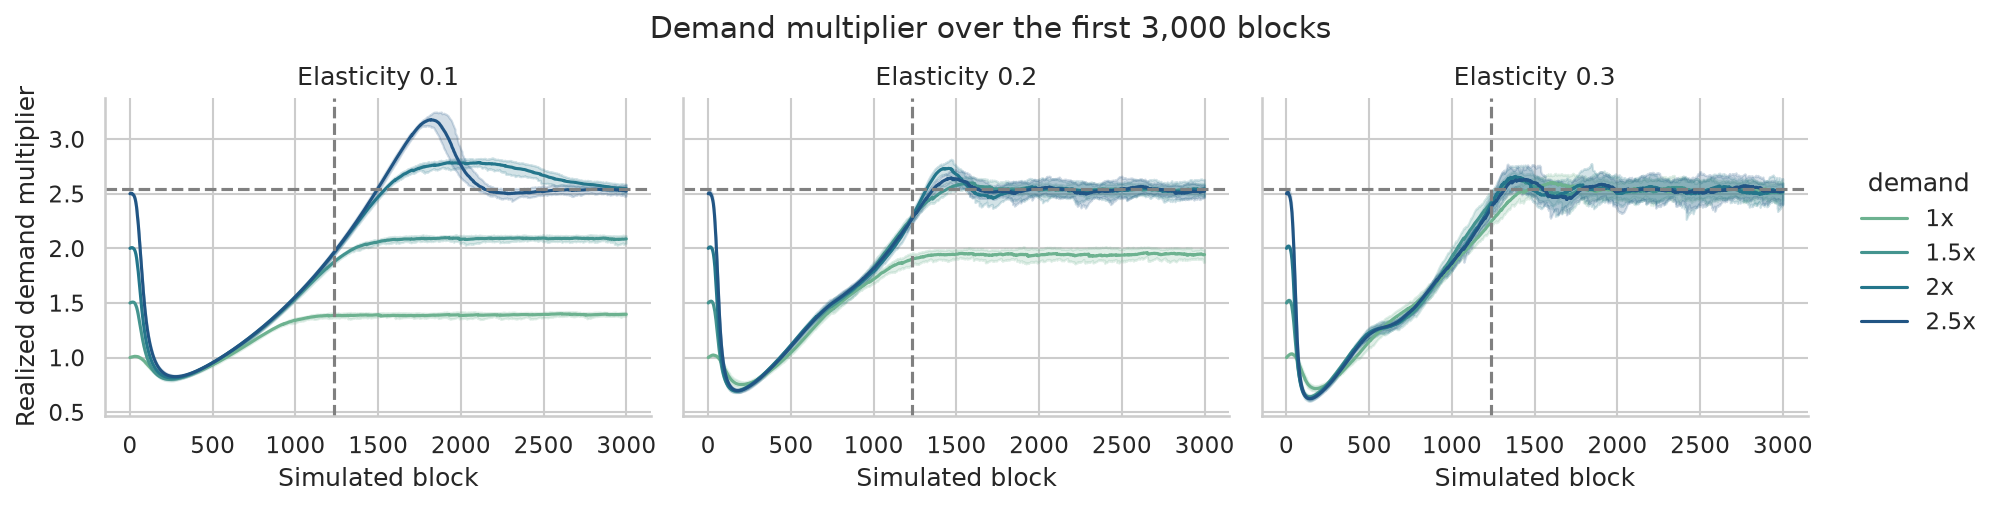

In [11]:
g = sns.relplot(
    data=steps_df,
    kind="line",
    x="block",
    y="demand_multiplier",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=ceiling, color="grey")
g.refline(x=ramp_end, color="grey")
g.set(xlabel="Simulated block", ylabel="Realized demand multiplier")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Demand multiplier over the first {zoom_blocks:,} blocks", y=1.05)
plt.savefig(os.path.join(figs_dir, "demand_multiplier_transient.png"), bbox_inches="tight")
plt.show()

In [12]:
# phi is the ratio of the capacity measure max(execution, state) to the demand
# measure execution + state. If the implied and observed values agree, the ceiling
# really is the quantity that makes arrivals equal the 1559 target.
implied_phi = (gas_limit / 2) / (ceiling * reference_gas)
observed_phi = (cells_df["utilization"] * gas_limit) / (cells_df["demand_multiplier"] * reference_gas)
print(f"ceiling m*   = {ceiling:.4f}")
print(f"phi implied  = {implied_phi:.4f}")
print(f"phi observed = {observed_phi.median():.4f} "
      f"(range {observed_phi.min():.4f}-{observed_phi.max():.4f})")
cells_df[["elasticity", "demand", "regime", "demand_multiplier", "utilization", "base_fee_gwei"]].round(4)

ceiling m*   = 2.5435
phi implied  = 0.6410
phi observed = 0.6395 (range 0.6366-0.6592)


,elasticity,demand,regime,demand_multiplier,utilization,base_fee_gwei
0,0.1,1x,demand-limited,1.3969,0.2824,0.0000
1,0.1,1.5x,demand-limited,2.0940,0.4126,0.0000
2,0.1,2x,at target,2.5435,0.5015,0.0052
3,0.1,2.5x,at target,2.5381,0.5008,0.3127
4,0.2,1x,demand-limited,1.9540,0.3859,0.0000
5,0.2,1.5x,at target,2.5376,0.4963,0.0021
6,0.2,2x,at target,2.5369,0.4983,0.0602
7,0.2,2.5x,at target,2.5366,0.4968,0.3700
8,0.3,1x,at target,2.5421,0.4963,0.0002
9,0.3,1.5x,at target,2.5367,0.4965,0.0257


### Takeaways

- **Nine of the twelve cells converge on one quantity**, `m* = 2.544`, which is
  the quantity that makes arrivals equal the 1559 target:
  $\phi \cdot m^{*} \cdot g_{ref} = L/2$, with $g_{ref}$ the mean cohort gas,
  $L$ = 200M and $\phi$ the ratio of the capacity measure `max(execution, state)`
  to the demand measure `execution + state`. Implied $\phi$ = 0.641 against an
  observed 0.640, so this is the mechanism rather than a coincidence.
- **That is why utilization is capped.** Elasticity and demand level choose the
  *price* that clears, never the *quantity*. Most cells sit at the ceiling and
  differ only in price.
- The three demand-limited cells are exactly the weakest price responses:
  `(0.1, 1x)` at 1.40, `(0.1, 1.5x)` at 2.09 and `(0.2, 1x)` at 1.95. By
  `e = 0.3` even 1x latent demand reaches the ceiling on its own.

## Execution vs. state gas

Two capacity constraints share one limit. Shown at the highest included demand
level, where the pressure is greatest.

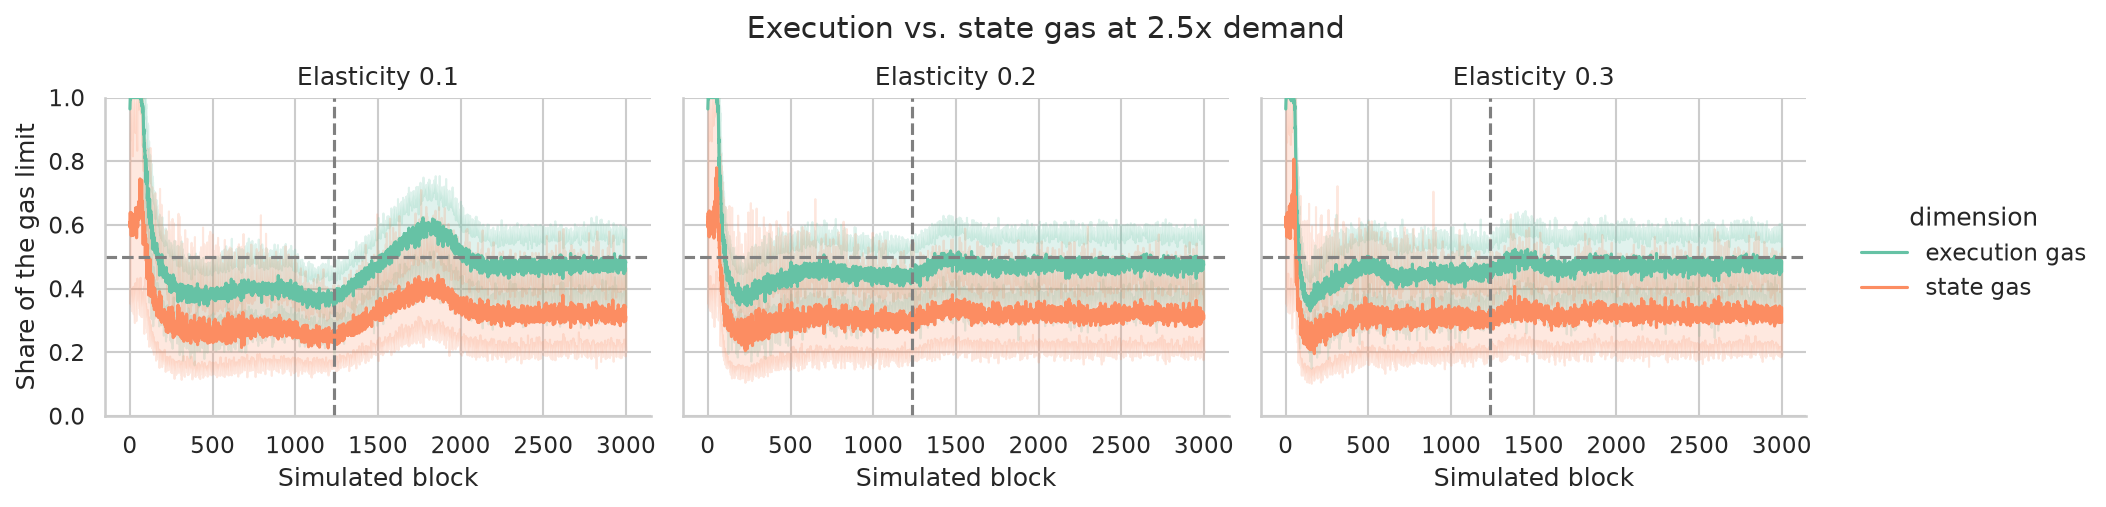

In [13]:
dims_df = steps_df.melt(
    id_vars=["elasticity", "demand", "run_index", "block"],
    value_vars=["execution_utilization", "state_utilization"],
    var_name="dimension",
    value_name="share_of_limit",
)
dims_df["dimension"] = dims_df["dimension"].map(
    {"execution_utilization": "execution gas", "state_utilization": "state gas"}
)

g = sns.relplot(
    data=dims_df[dims_df["demand"] == demand_order[-1]],
    kind="line",
    x="block",
    y="share_of_limit",
    hue="dimension",
    col="elasticity",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=0.5, color="grey")
g.refline(x=ramp_end, color="grey")
g.set(ylim=(0, 1), xlabel="Simulated block", ylabel="Share of the gas limit")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Execution vs. state gas at {demand_order[-1]} demand", y=1.05)
plt.savefig(os.path.join(figs_dir, "execution_vs_state.png"), bbox_inches="tight")
plt.show()

In [14]:
print("state gas as a share of execution gas:",
      round((cells_df["state_utilization"] / cells_df["execution_utilization"]).median(), 3))
cells_df[["elasticity", "demand", "execution_utilization", "state_utilization", "utilization"]].round(3)

state gas as a share of execution gas: 0.623


,elasticity,demand,execution_utilization,state_utilization,utilization
0,0.1,1x,0.273,0.161,0.282
1,0.1,1.5x,0.402,0.246,0.413
2,0.1,2x,0.489,0.304,0.502
3,0.1,2.5x,0.488,0.304,0.501
4,0.2,1x,0.375,0.230,0.386
5,0.2,1.5x,0.484,0.302,0.496
6,0.2,2x,0.486,0.301,0.498
7,0.2,2.5x,0.484,0.302,0.497
8,0.3,1x,0.483,0.301,0.496
9,0.3,1.5x,0.484,0.302,0.497


### Takeaways

- **Execution gas is the binding dimension.** State gas runs at ~62% of execution
  gas and never approaches the limit, so `gas_used = max(execution, state)` is the
  execution figure in effectively every block.
- Note that 85% of the trace's state gas sits in `schedule_gas_rescuable` rows
  (see `replay_outcome_summary.csv`). Those rows *are* simulated, so this is
  already the optimistic case for state demand.

## Backlog

The high-demand cells end with tens of thousands of queued transactions, which
looks like congestion. `eligible_backlog_txs` counts only the queue that could
actually be included at the current base fee.

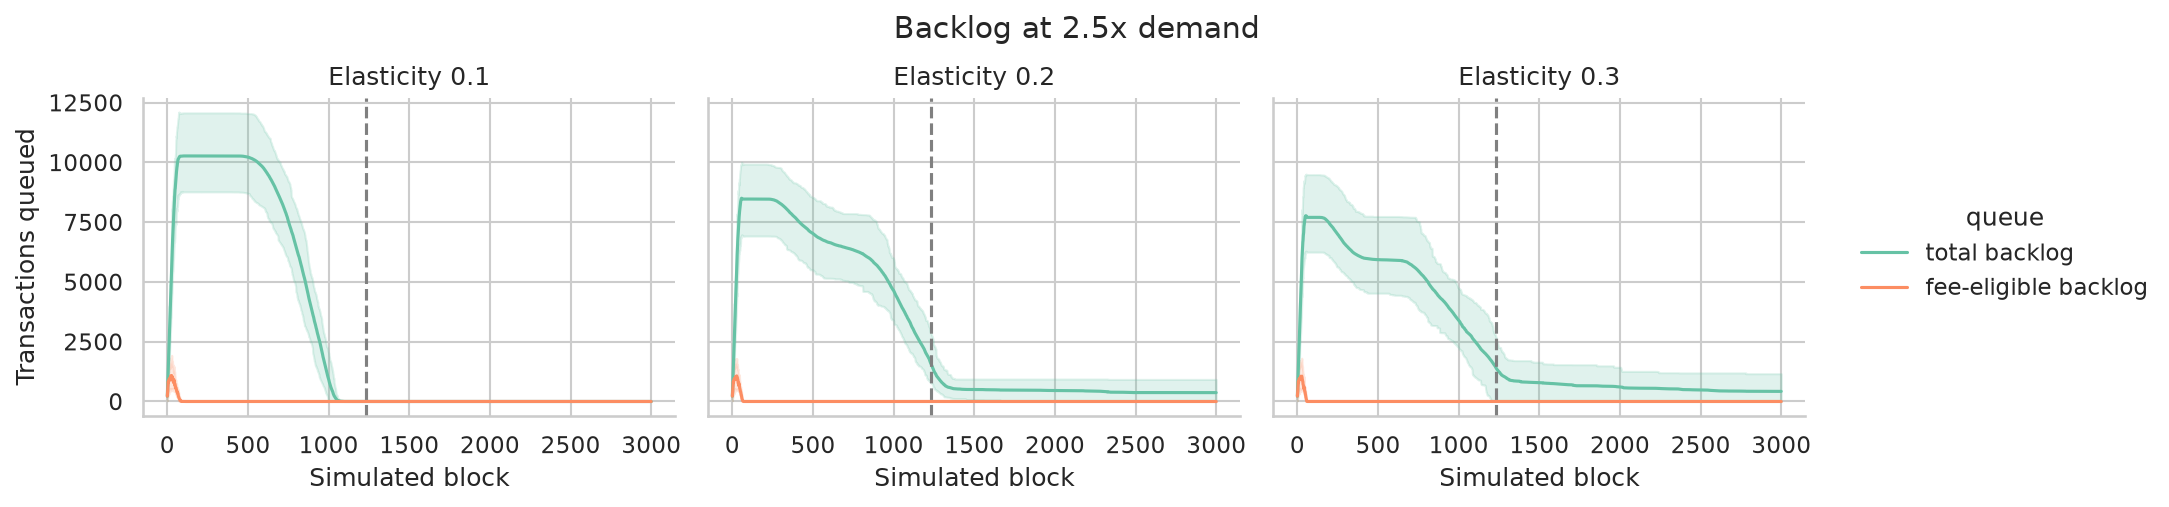

In [15]:
queue_df = steps_df.melt(
    id_vars=["elasticity", "demand", "run_index", "block"],
    value_vars=["backlog_txs", "eligible_backlog_txs"],
    var_name="queue",
    value_name="transactions",
)
queue_df["queue"] = queue_df["queue"].map(
    {"backlog_txs": "total backlog", "eligible_backlog_txs": "fee-eligible backlog"}
)

g = sns.relplot(
    data=queue_df[queue_df["demand"] == demand_order[-1]],
    kind="line",
    x="block",
    y="transactions",
    hue="queue",
    col="elasticity",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(x=ramp_end, color="grey")
g.set(xlabel="Simulated block", ylabel="Transactions queued")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle(f"Backlog at {demand_order[-1]} demand", y=1.05)
plt.savefig(os.path.join(figs_dir, "backlog.png"), bbox_inches="tight")
plt.show()

In [16]:
print("largest fee-eligible backlog in any cell:", cells_df["eligible_backlog_txs"].max())
cells_df[["elasticity", "demand", "backlog_txs", "eligible_backlog_txs"]].round(0)

largest fee-eligible backlog in any cell: 0.0


,elasticity,demand,backlog_txs,eligible_backlog_txs
0,0.0,1x,0.0,0.0
1,0.0,1.5x,0.0,0.0
2,0.0,2x,0.0,0.0
3,0.0,2.5x,0.0,0.0
4,0.0,1x,0.0,0.0
5,0.0,1.5x,0.0,0.0
6,0.0,2x,0.0,0.0
7,0.0,2.5x,199.0,0.0
8,0.0,1x,0.0,0.0
9,0.0,1.5x,0.0,0.0


### Takeaways

- **There is essentially no backlog in this run.** Nine cells end with an empty
  queue; the largest median is 199 transactions at `(0.2, 2.5x)`. Compare the
  previous 3x-4x sweep, which stranded tens of thousands.
- **Fee-eligible backlog is 0 in every cell.** Whatever queues is priced below the
  current base fee, so it is stranded history rather than unmet demand: they were
  admitted while the fee was low and `adapt_bids` reprices arrivals, never the
  existing pool.
- So no cell in this grid exhibits congestion. Read the eligible series before
  calling any backlog congestion.

## Clearing price by demand level

Utilization is capped by the mechanism, so this is the sweep's real result: the
base fee needed to clear a given level of latent demand at a 200M limit.

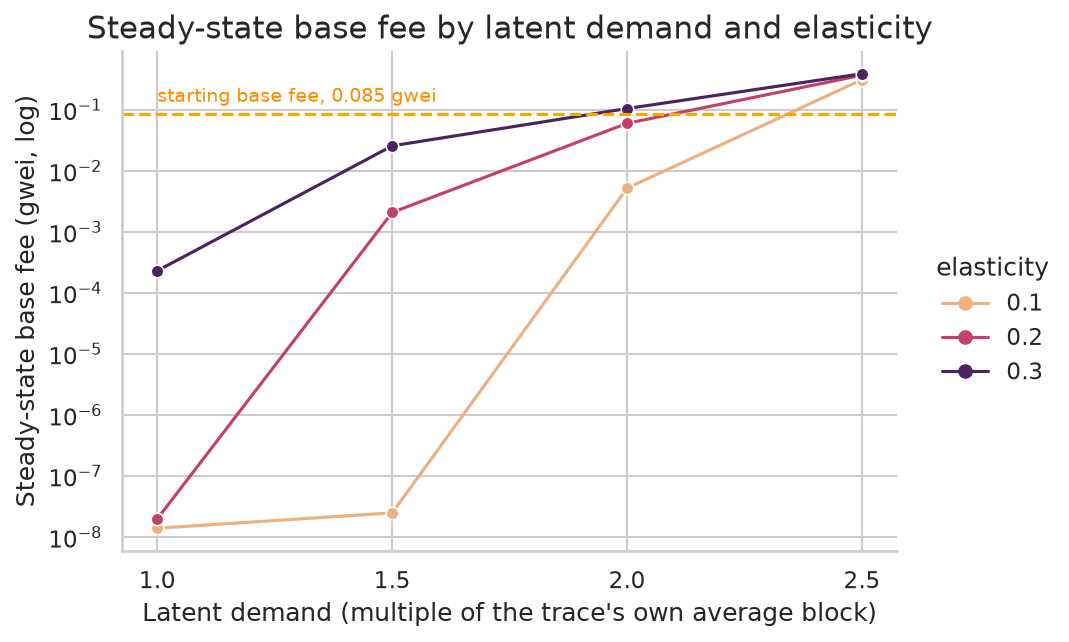

In [17]:
g = sns.relplot(
    data=cells_df,
    kind="line",
    x="demand_level",
    y="base_fee_gwei",
    hue="elasticity",
    palette="flare",
    marker="o",
    height=4.2,
    aspect=1.5,
)
g.refline(y=start_fee_gwei, color="orange")
g.ax.text(
    1.0, start_fee_gwei * 1.6,
    f"starting base fee, {start_fee_gwei:.3f} gwei",
    color="darkorange", fontsize=9,
)
g.set(
    yscale="log",
    xticks=sorted(cells_df["demand_level"].unique()),
    title="Steady-state base fee by latent demand and elasticity",
    xlabel="Latent demand (multiple of the trace's own average block)",
    ylabel="Steady-state base fee (gwei, log)",
)
plt.savefig(os.path.join(figs_dir, "clearing_price.png"), bbox_inches="tight")
plt.show()

In [18]:
spread_df = cells_df.pivot(index="demand", columns="elasticity", values="base_fee_gwei").reindex(demand_order)
top_row = spread_df.loc[demand_order[-1]]
print(f"at {demand_order[-1]} the elasticity assumption alone moves the clearing fee "
      f"{top_row.max() / top_row.min():,.0f}x "
      f"({top_row.min():,.2f} to {top_row.max():,.2f} gwei)")

# Where does each elasticity cross back above the fee the chain started at?
above = spread_df[spread_df > start_fee_gwei].apply(lambda col: col.first_valid_index())
print()
print("lowest demand level whose clearing fee exceeds the starting base fee:")
print(above.to_string())
spread_df.round(4)

at 2.5x the elasticity assumption alone moves the clearing fee 1x (0.31 to 0.39 gwei)

lowest demand level whose clearing fee exceeds the starting base fee:
elasticity
0.1    2.5x
0.2    2.5x
0.3      2x


elasticity,0.1,0.2,0.3
demand,,,
1x,0.0000,0.0000,0.0002
1.5x,0.0000,0.0021,0.0257
2x,0.0052,0.0602,0.1052
2.5x,0.3127,0.3700,0.3911


### Takeaways

- **The lines cross at ~2.5x, and the crossing is the point.** Below it, a *more*
  elastic demand curve sustains a *higher* fee: it expands strongly as the fee
  falls, so it reaches the target and holds a price, where an inelastic curve
  barely responds, leaves blocks under-full and lets the fee collapse toward its
  floor. Above ~2.5x the ordering reverses - an elastic curve sheds the excess
  cheaply while an inelastic one has to be priced out.
- The crossing sits near the demand level at which the trace's own historical
  price is already the clearing price.
- So the elasticity assumption does not merely scale the answer, it decides the
  **direction** in which the answer is wrong if the assumption is wrong.
- **This grid stops right at the crossing, which is why elasticity looks
  irrelevant here.** At 2.5x the three curves span only 0.31 to 0.39 gwei, a 1.25x
  spread. That is not evidence the assumption does not matter - it is evidence
  that 2.5x is the demand level where the assumption happens not to. The previous
  sweep, which reached 4x, saw a 25x spread at its top level.
- **The orange rule is the base fee the chain actually started at**, 0.085 gwei,
  where a 60M-limit mainnet sat at the head of the source trace. It splits the
  chart into "moving to 200M makes gas cheaper than it was" below and "more
  expensive" above.
- Every curve crosses it late: `e = 0.3` at 2x, `e = 0.1` and `e = 0.2` not until
  2.5x. So across almost the whole of this grid, **a 200M limit leaves gas cheaper
  than it was before the increase.**

## Utilization distribution

The medians hide whether utilization is steady near the target or merely averages
there. Post-ramp blocks only, 20,000 sampled per cell.

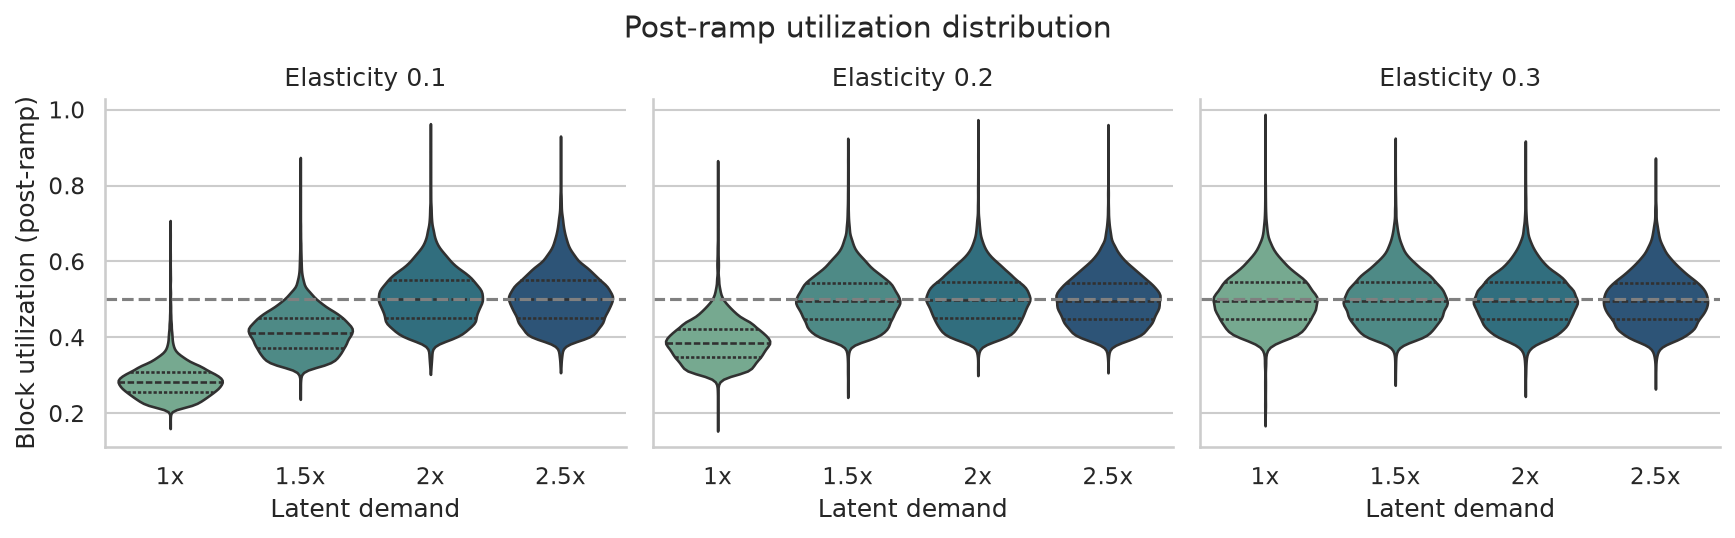

In [19]:
g = sns.catplot(
    data=steady_df,
    kind="violin",
    x="demand",
    y="utilization",
    order=demand_order,
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    legend=False,
    cut=0,
    inner="quartile",
    density_norm="width",
    height=3.4,
    aspect=1.15,
)
g.refline(y=0.5, color="grey")
g.set(xlabel="Latent demand", ylabel="Block utilization (post-ramp)")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle("Post-ramp utilization distribution", y=1.05)
plt.savefig(os.path.join(figs_dir, "utilization_distribution.png"), bbox_inches="tight")
plt.show()

In [20]:
print("blocks at >= 99% of the limit, worst cell:", round(cells_df["saturated_share"].max(), 5))
print("maximum post-ramp utilization anywhere:", round(steady_df["utilization"].max(), 3))
steady_df.groupby(["elasticity", "demand"])["utilization"].describe(
    percentiles=[0.01, 0.5, 0.99]
)[["mean", "std", "1%", "50%", "99%"]].round(3)

blocks at >= 99% of the limit, worst cell: 0.0
maximum post-ramp utilization anywhere: 0.988


mean    std     1%    50%    99%
elasticity demand                                   
0.1        1.5x    0.415  0.057  0.320  0.413  0.571
           1x      0.286  0.044  0.215  0.282  0.430
           2.5x    0.505  0.072  0.384  0.501  0.704
           2x      0.505  0.070  0.383  0.502  0.685
0.2        1.5x    0.500  0.067  0.386  0.496  0.669
           1x      0.389  0.055  0.296  0.386  0.543
           2.5x    0.500  0.067  0.385  0.497  0.674
           2x      0.501  0.067  0.386  0.498  0.678
0.3        1.5x    0.501  0.068  0.382  0.497  0.678
           1x      0.499  0.069  0.374  0.496  0.673
           2.5x    0.500  0.068  0.376  0.496  0.677
           2x      0.500  0.069  0.373  0.496  0.680

### Takeaways

- **The bulk shifts upward with demand at `e = 0.1`** and is already at the target
  across the whole `e = 0.3` panel. That is the demand-limited to at-target
  transition, seen as a distribution rather than a median.
- **Post-ramp, nothing saturates.** The highest utilization in any post-ramp block
  anywhere is 98.8%, and no cell has a single block at or above 99% of the limit.
- All the saturation this run reports lives in the **ramp phase**: the
  `execution_saturated_share` in `scenario_summary.csv` runs 0.3-1.2%, and the
  ramp is only the first 1,234 blocks, where capacity is still near 60M.
- Careful with two different saturation numbers. The share above is
  `max(execution, state) >= 99%` over **post-ramp** blocks. The
  `execution_saturated_share` in `scenario_summary.csv` is execution-only over
  **all** blocks, ramp included, so it is the larger figure. Cite one or the
  other, and say which.

## Is the run long enough?

With a 7,200-block horizon the ramp is the first 1,234 blocks, so anything called
"steady state" is only the ~6,000 blocks after it. This compares the second and
fourth quarters of that post-ramp window: if the base fee is still drifting, the
clearing prices below are a snapshot of a moving quantity rather than an
equilibrium.

Read the **absolute** fee move, not the ratio. Cells whose fee sits near zero in
both windows produce enormous ratios from negligible movement - `(0.1, 2x)` shows
a 781x ratio on a change from 0.000008 to 0.006 gwei, which is nothing.

In [21]:
post_ramp_df = window_df[window_df["block"] >= ramp_end].copy()
lo, hi = post_ramp_df["block"].min(), post_ramp_df["block"].max()
quarter = (hi - lo) / 4
early = post_ramp_df[post_ramp_df["block"] < lo + quarter]
late = post_ramp_df[post_ramp_df["block"] >= hi - quarter]

drift_df = (
    early.groupby(["elasticity", "demand"])[["base_fee_gwei", "utilization"]].median()
    .join(
        late.groupby(["elasticity", "demand"])[["base_fee_gwei", "utilization"]].median(),
        lsuffix="_early", rsuffix="_late",
    )
    .reset_index()
)
drift_df["fee_ratio"] = drift_df["base_fee_gwei_late"] / drift_df["base_fee_gwei_early"]
# The ratio explodes on cells whose fee is near zero in both windows, so the
# absolute move is what decides whether a cell has actually settled.
drift_df["fee_change_gwei"] = drift_df["base_fee_gwei_late"] - drift_df["base_fee_gwei_early"]
drift_df["utilization_change_pp"] = (
    100 * (drift_df["utilization_late"] - drift_df["utilization_early"])
)
print(f"comparing blocks {lo:,.0f}-{lo + quarter:,.0f} against {hi - quarter:,.0f}-{hi:,.0f}")
print("largest utilization move:", round(drift_df["utilization_change_pp"].abs().max(), 2), "pp")
print("largest absolute fee move:", round(drift_df["fee_change_gwei"].abs().max(), 4), "gwei")
drift_df[["elasticity", "demand", "base_fee_gwei_early", "base_fee_gwei_late",
          "fee_change_gwei", "fee_ratio", "utilization_change_pp"]].round(4)

comparing blocks 1,248-2,730 against 5,694-7,176
largest utilization move: 2.73 pp
largest absolute fee move: 0.1498 gwei


,elasticity,demand,base_fee_gwei_early,base_fee_gwei_late,fee_change_gwei,fee_ratio,utilization_change_pp
0,0.1,1.5x,0.0000,0.0000,0.0000,1.0171,0.2792
1,0.1,1x,0.0000,0.0000,-0.0000,0.9613,-0.0031
2,0.1,2.5x,0.1714,0.3211,0.1498,1.8739,-0.6818
3,0.1,2x,0.0000,0.0060,0.0060,780.9910,-2.7256
4,0.2,1.5x,0.0019,0.0021,0.0002,1.1015,-0.0574
5,0.2,1x,0.0000,0.0000,-0.0000,0.9800,0.0439
6,0.2,2.5x,0.3533,0.3784,0.0251,1.0709,-0.1375
7,0.2,2x,0.0579,0.0609,0.0030,1.0511,-0.1913
8,0.3,1.5x,0.0255,0.0257,0.0003,1.0107,-0.1374
9,0.3,1x,0.0002,0.0002,0.0001,1.2751,0.0918


### Takeaways

- **Utilization has converged.** The largest move between the two windows is 2.7
  percentage points and most cells are within 0.2pp, so the utilization results
  below are equilibrium values.
- **Fees have mostly converged, with one real exception.** `(e=0.1, 2.5x)` climbs
  from 0.171 to 0.321 gwei across the window - still nearly doubling - so its
  clearing price is a lower bound, not a settled value. Every other cell moves by
  less than 0.03 gwei.
- The pattern is the expected one: **the weaker the price response, the slower the
  fee converges.** All three `e = 0.1` cells above 1.5x are the slow ones, which
  is also why the previous 93,807-block sweep needed its full horizon.
- So treat `e = 0.1` clearing prices in this run as provisional and the `e = 0.2`
  and `e = 0.3` ones as settled.

## Appendix: the full simulation window

The sections above zoom into the first 3,000 blocks. This is the remaining ~4,200,
binned to ~300 points. If these ever stop being flat, the zoomed sections are
hiding something and the window needs widening.

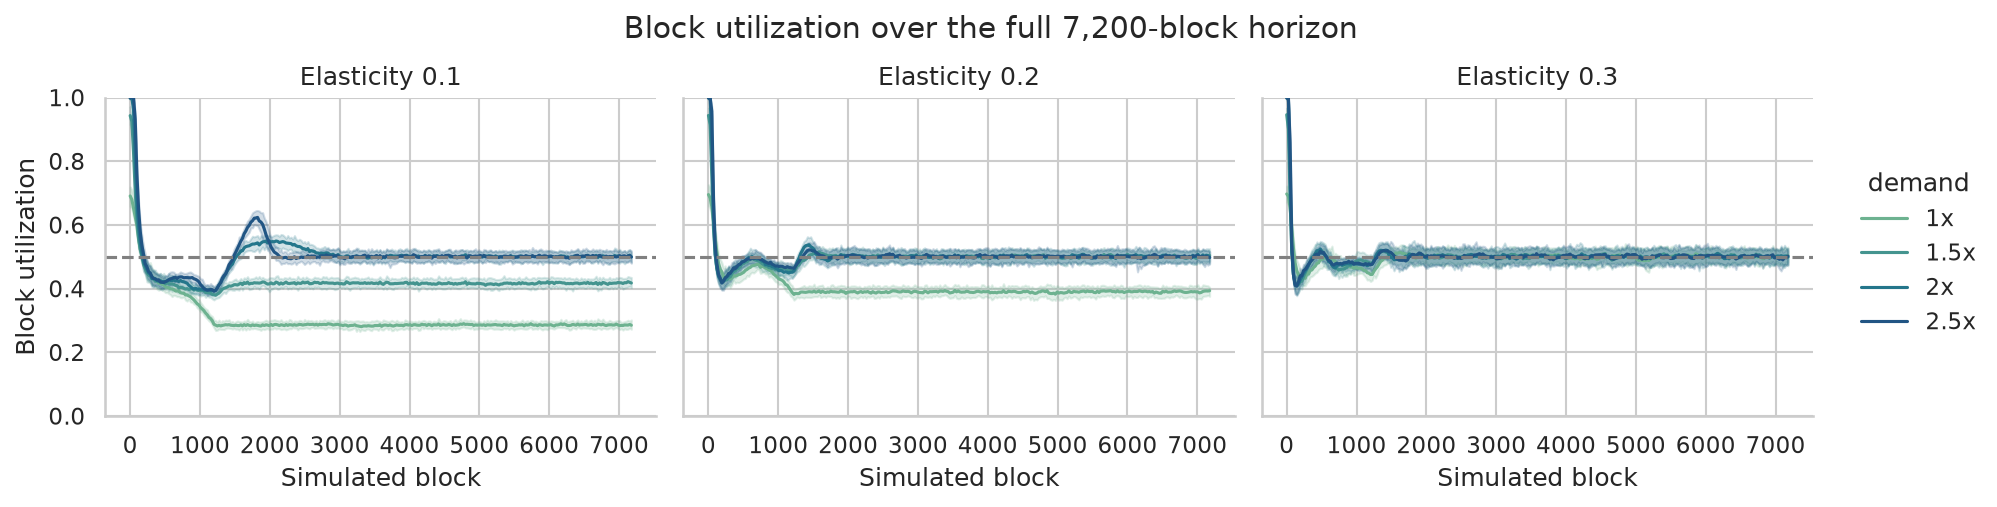

In [22]:
g = sns.relplot(
    data=window_df,
    kind="line",
    x="block",
    y="utilization",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.refline(y=0.5, color="grey")
g.set(ylim=(0, 1), xlabel="Simulated block", ylabel="Block utilization")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle("Block utilization over the full 7,200-block horizon", y=1.05)
plt.show()

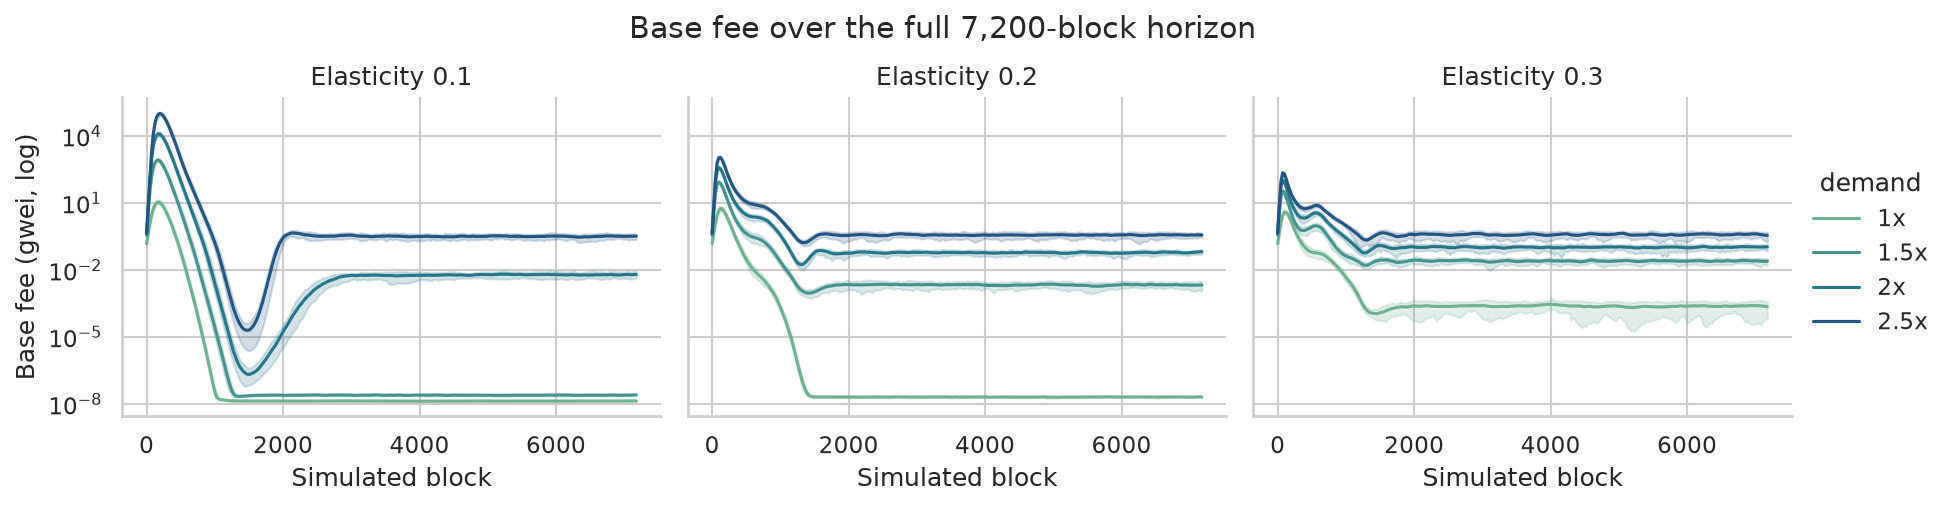

In [23]:
g = sns.relplot(
    data=window_df,
    kind="line",
    x="block",
    y="base_fee_gwei",
    hue="demand",
    hue_order=demand_order,
    col="elasticity",
    palette="crest",
    errorbar=("pi", 80),
    height=3.2,
    aspect=1.3,
)
g.set(yscale="log", xlabel="Simulated block", ylabel="Base fee (gwei, log)")
g.set_titles("Elasticity {col_name}")
g.figure.suptitle("Base fee over the full 7,200-block horizon", y=1.05)
plt.show()

## Caveats to carry into the report

1. **Utilization is capped by the mechanism, not measured from the data.**
   EIP-1559 targets 50% and the demand model raises the fee until arrivals fall
   back to it, so ~48% is the most this model can produce at any demand level. Do
   not report the flat utilization as evidence that 200M "is enough" - report the
   clearing price instead.
2. **The ramp transient assumes demand arrives before capacity.** Full latent
   demand applies from block 0 against a 60M starting limit, which is what
   produces the fee spike. Real demand growth would arrive gradually. Steady-state
   numbers are unaffected, but the peak is not a forecast.
3. **The horizon is one day.** 7,200 blocks, of which the ramp is the first 1,234,
   so "steady state" is the ~6,000 blocks after it rather than a long-run
   equilibrium. See the convergence check.
4. **Backlog is largely fee-ineligible residue** rather than unmet demand - see
   the backlog section for this run's figures.
5. **85% of the trace's state gas sits in `schedule_gas_rescuable` rows.** Those
   are simulated, so state-gas demand here is already the optimistic case; it
   depends on senders raising their signed gas limits, which the model does not
   predict.
6. **`demand_level = 1` is a lower bound on real demand**, not a forecast: the
   trace contains only transactions that were actually included.
7. **The composition pool is fixed at L = 16** in both runs, so nothing here tests
   sensitivity to it. `--pool-blocks 8 16 64` would.
8. **One aggregate elasticity** covers both gas dimensions, so the model cannot
   represent substitution between execution and state demand.